# CAP Surface & Volumetric Visualization

This notebook generates CAPs surface and subcortical maps used in figure 1.

- **Z-score CAPs** - Raw CAP centroid images are loaded, masked with the full brain atlas, z-scored across ROIs within each CAP and saved as a new NIfTI file.
- **Cortical surface plot** - Z-scored CAP is projected onto the fsaverage5 cortical surface (`nilearn.surface.vol_to_surf`) and BrainSpace's `plot_hemispheres`.
- **Subcortical volumetric plot** - Subcortical activation (atlas labels > 1000) is displayed as an axial mosaic (5 slices) using nilearn.

**Input:** Raw CAP centroid images (`CAPcenter_paired_nclust-{k}.nii.gz`)  
**Output:** Per-CAP PNG files saved to `results/main_figures/01_caps_surf&vol_fig/`

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
from nilearn import plotting, datasets
from IPython.display import Image, display
from scipy import stats
import os
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import stats
from nilearn.plotting import plot_stat_map
from termcolor import cprint
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
from nilearn import plotting, datasets, surface
import os
import numpy as np
import nibabel as nib
import warnings
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
from brainspace.plotting import plot_hemispheres, plot_surf
from IPython.display import Image, display
from brainspace.mesh.mesh_io import read_surface
from scipy.stats import zscore
import seaborn as sns
from joypy import joyplot
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
from dotenv import load_dotenv


In [2]:
load_dotenv()
base_dir = os.environ['BASE_DIR']
runs_str = "run-ON"

results_dir = os.environ['RESULTS_DIR']
results_fig_dir = os.path.join(results_dir, "main_figures", "01_caps_surf&vol_fig")

### Create subcortical masker

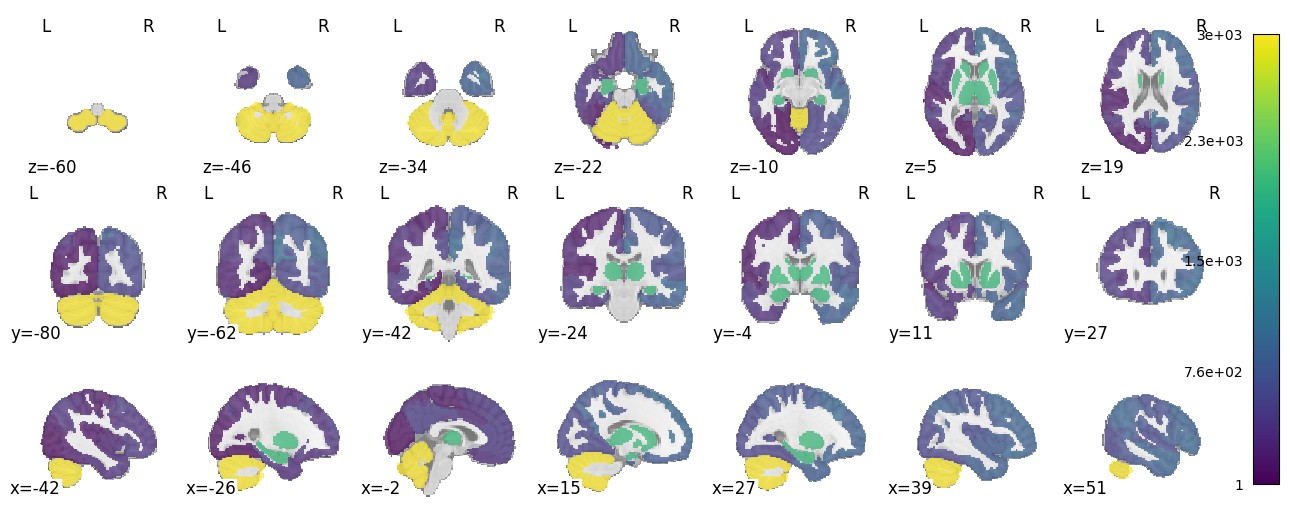

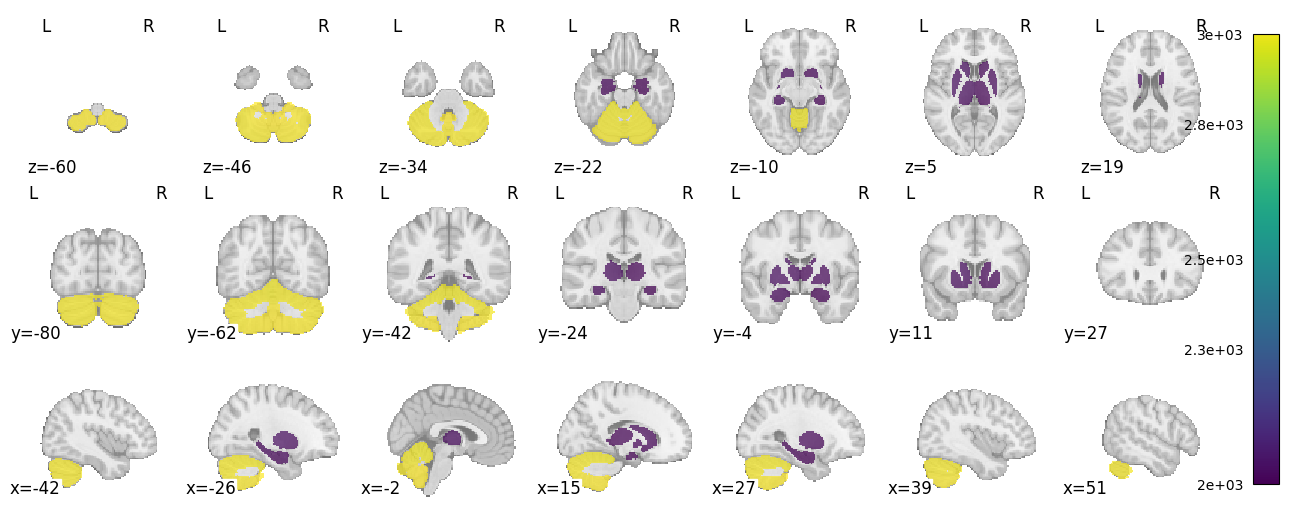

In [3]:
atlas_dir = os.environ['ATLAS_DIR']

atlas_filename = os.path.join(atlas_dir, "atlas_combined_tpl-MNI152NLin2009cAsym_res-02_T1w.nii.gz")


subcortical_atlas_filename = os.path.join(atlas_dir, "atlas_subcortical.nii.gz")

atlas_masker = NiftiLabelsMasker(labels_img=atlas_filename, mask_img=None, standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)

atlas_masker.fit()

atlas_labels = nib.load(atlas_masker.labels_img).get_fdata()

sub_cortical_labels = np.where(atlas_labels > 1000, atlas_labels, 0)

sub_cortical_mask = nib.Nifti1Image(sub_cortical_labels, affine=atlas_masker.labels_img_.affine)

nib.save(sub_cortical_mask, subcortical_atlas_filename)

sub_cortical_atlas = NiftiLabelsMasker(labels_img=subcortical_atlas_filename, mask_img=None,  standardize=False, standardize_confounds=True, memory="nilearn_cache", verbose=0)

plotting.plot_roi(atlas_filename, display_mode="mosaic", cmap="viridis", colorbar=True)

plotting.plot_roi(subcortical_atlas_filename, display_mode="mosaic", cmap="viridis", colorbar=True)

### Load fsaverage 5

In [4]:
fsavg_ver = 5 
fsavg_dir = os.environ['FSAVG_DIR']
runs_str = "run-ON"
os.path.exists(fsavg_dir)

True

In [5]:
num_points = 10242  #10242
fsaverage = datasets.fetch_surf_fsaverage(f"fsaverage{fsavg_ver}")

# surf_lh_fs = nib.freesurfer.read_geometry(os.path.join(fsavg_dir,'surf/lh.pial'))
# surf_rh_fs = nib.freesurfer.read_geometry(os.path.join(fsavg_dir,'surf/rh.pial'))

surf_lh_fs = read_surface(fsaverage["pial_left"])
surf_rh_fs = read_surface(fsaverage["pial_right"])

# Create cortical indcies mask for fsaverage 4/5
# 1-load cort
cort_lh = nib.freesurfer.read_label(os.path.join(fsavg_dir,"label/lh.cortex.label"))
cort_rh = nib.freesurfer.read_label(os.path.join(fsavg_dir,"label/rh.cortex.label"))
cort = np.concatenate((cort_lh, cort_rh + num_points))
print(cort.shape)
print(cort.max())
print(num_points + cort_rh.max())

## 2-mask
print("Mask both hemispheres")
cap_indices = np.arange(num_points * 2)
mask = np.isin(cap_indices, cort)
print(mask.shape)
print(np.count_nonzero(mask))
print(mask[0:10])

print("Mask left hemisphere")
left_cap_indices = np.arange(num_points)
mask_l = np.isin(left_cap_indices, cort_lh)
print(mask_l.shape)
print(np.count_nonzero(mask_l))
print(mask_l[0:10])

print("Mask right hemisphere")
right_cap_indices = np.arange(num_points)
mask_r = np.isin(right_cap_indices, cort_rh)
print(mask_r.shape)
print(np.count_nonzero(mask_r))
print(mask_r[0:10])

(18715,)
20483
20483
Mask both hemispheres
(20484,)
18715
[ True  True  True  True  True  True  True  True False  True]
Mask left hemisphere
(10242,)
9354
[ True  True  True  True  True  True  True  True False  True]
Mask right hemisphere
(10242,)
9361
[ True  True  True  True  True  True  True  True  True  True]


### Yeo networks

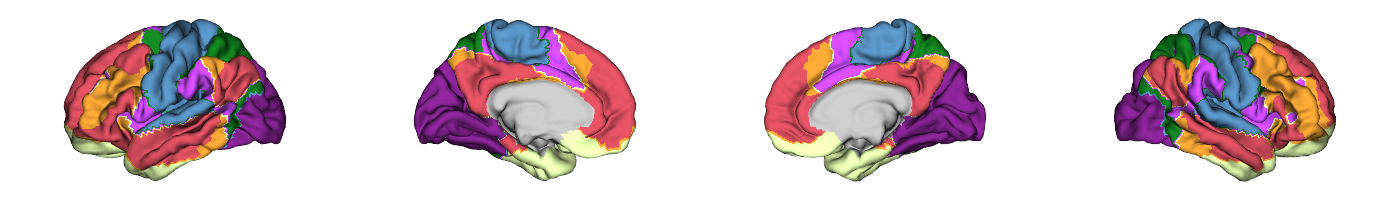

In [6]:
from brainstat.datasets import fetch_yeo_networks_metadata
from brainstat.datasets import fetch_parcellation
from brainspace.datasets import load_fsa5
from matplotlib import colormaps
import matplotlib.colors as colors

surf_lh, surf_rh = load_fsa5(with_normals=True)
yeo_networks = fetch_parcellation("fsaverage5", "yeo", 7)
network_names, yeo_colormap = fetch_yeo_networks_metadata(7)
yeo_networks_masked = np.where(mask, yeo_networks, np.nan)

yeoColors = colors.ListedColormap(yeo_colormap, name='Yeo')
colormaps.register(yeoColors)
cmap = colormaps.get_cmap('Yeo')
plot_hemispheres(
    surf_lh,
    surf_rh,
    yeo_networks_masked,
    embed_nb=True,
    cmap='Yeo',
    nan_color=(0.7, 0.7, 0.7, 1),
    size=(1400, 200),
    zoom=1.45,
)

In [7]:
from brainspace.datasets import load_fsa5
surf_lh, surf_rh = load_fsa5(with_normals=True)
yeo_nets_dict = {1: 'VN', 2: 'SMN', 3: 'DAN', 4: 'SN', 5: 'LN', 6: 'FPN', 7: 'DMN'}
yeo_networks = fetch_parcellation(template="fsaverage5",
                                  atlas="yeo",
                                  n_regions=7,
                                  join=True)

### Z score caps

In [8]:
k=7
# Load CAP data
cap_file_in = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                        f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}.nii.gz')

cap_file_out_zscored = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                        f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}_zscored.nii.gz')

cap_img = nib.load(cap_file_in)

# Transform data using masker
cap_data_masked = atlas_masker.transform(cap_img)  # Will be (n_caps, n_voxels)

# Z-score the masked data
z_scored_masked = stats.zscore(cap_data_masked, axis=1)  # Z-score each CAP

# Transform back to image space
z_scored_caps = atlas_masker.inverse_transform(z_scored_masked)

# save z-scored CAPs
nib.save(z_scored_caps, cap_file_out_zscored)

In [9]:
caps_file = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                        f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}_zscored.nii.gz')
caps_v = atlas_masker.transform(caps_file).flatten()
print(caps_v.shape)
print(caps_v.max())
print(caps_v.min())

(7420,)
4.5046663
-4.472434


### Generate caps maps for figure 1

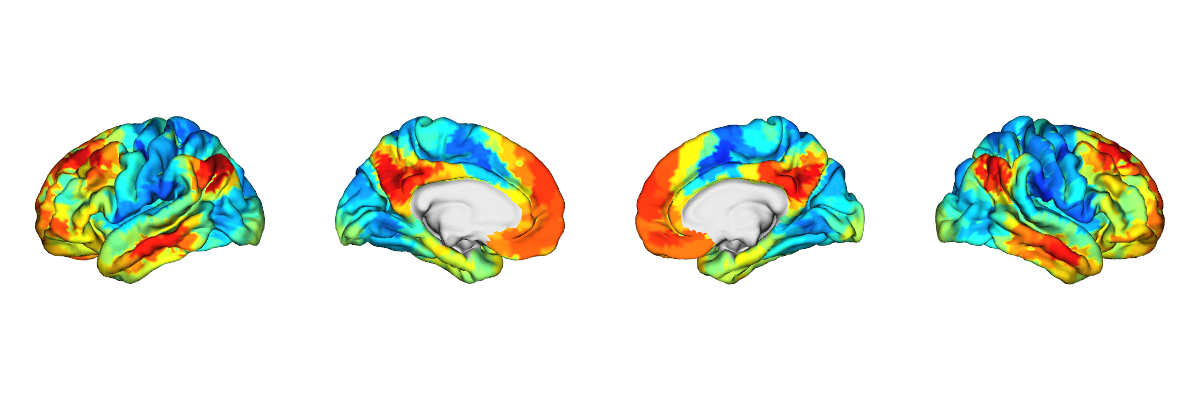

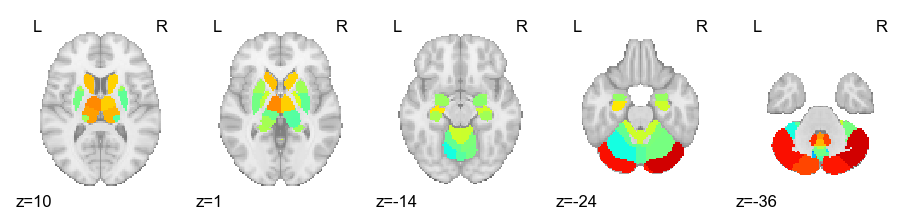

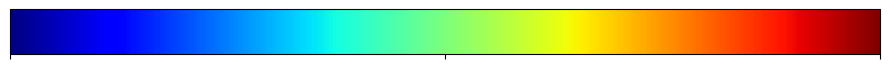

CAP 1 color range:
['-2.4', '0.0', '2.4']




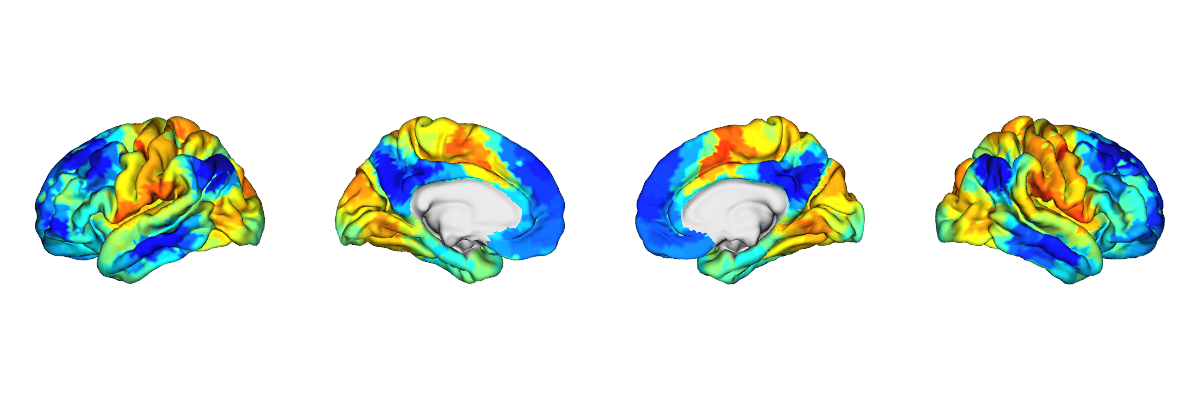

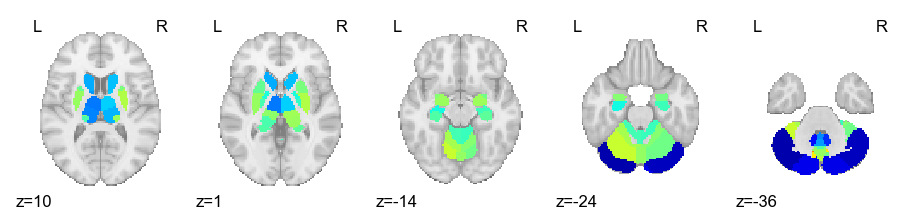

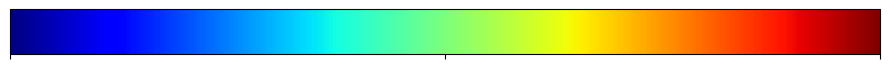

CAP 2 color range:
['-2.3', '0.0', '2.3']




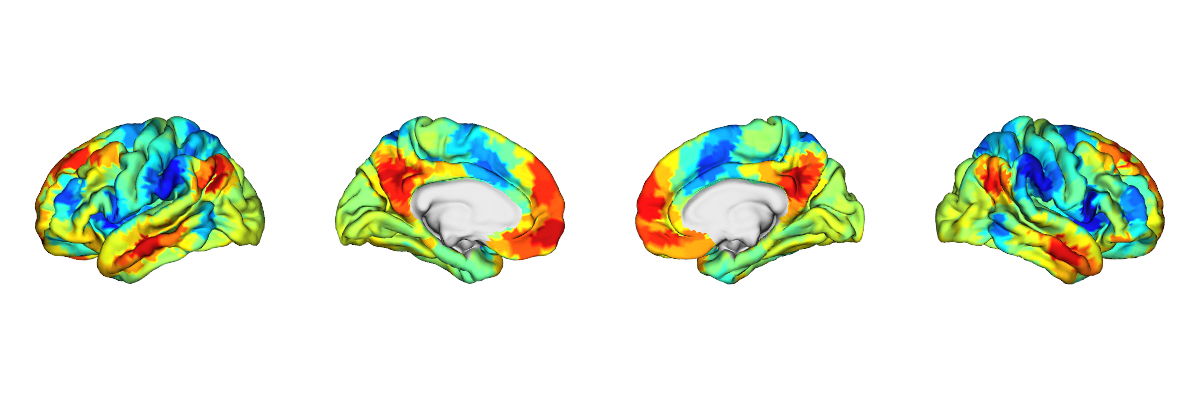

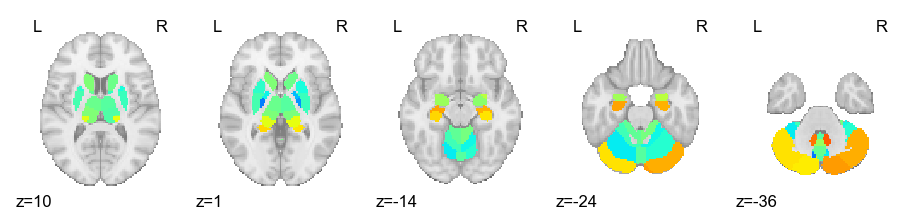

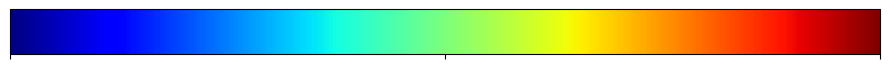

CAP 3 color range:
['-2.7', '0.0', '2.7']




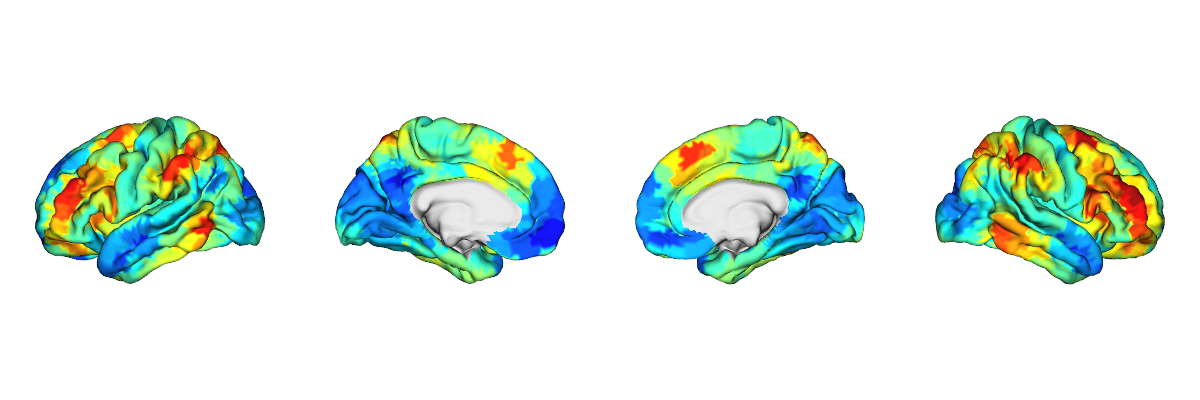

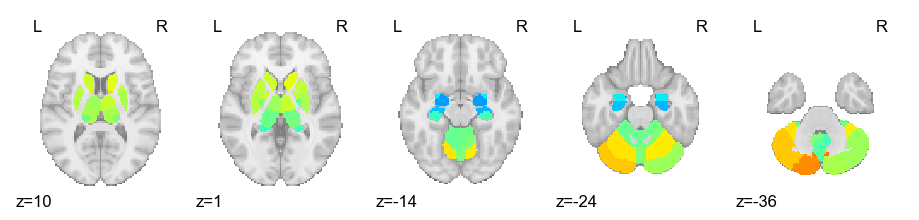

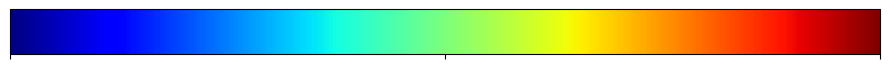

CAP 4 color range:
['-2.7', '0.0', '2.7']




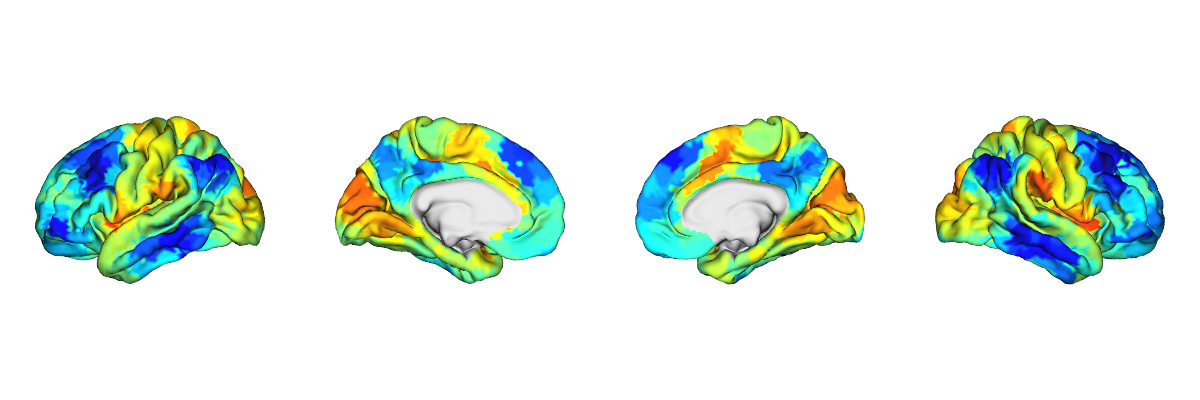

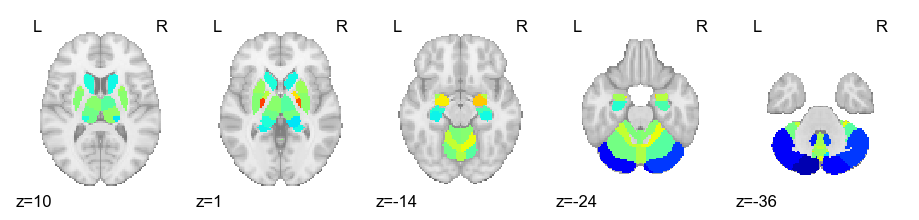

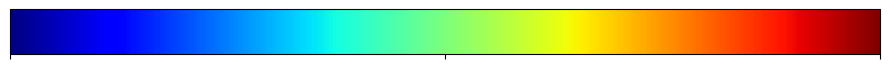

CAP 5 color range:
['-2.7', '0.0', '2.7']




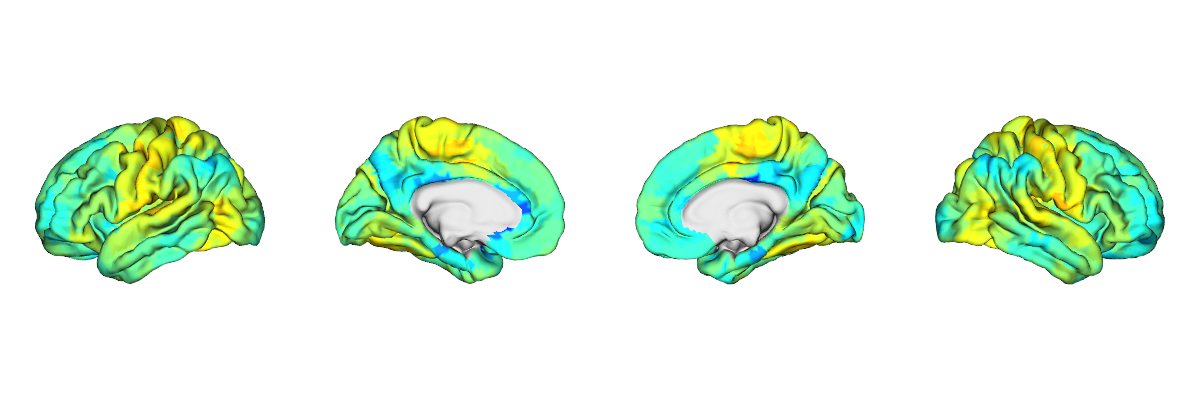

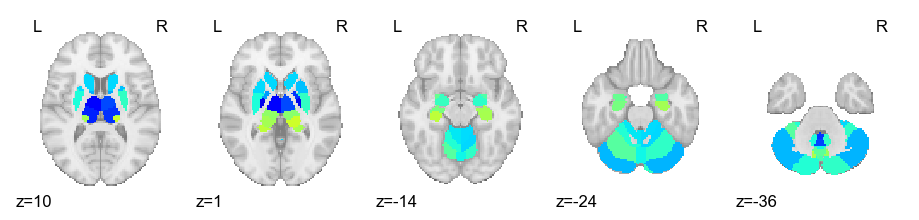

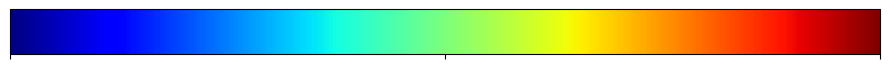

CAP 6 color range:
['-4.5', '0.0', '4.5']




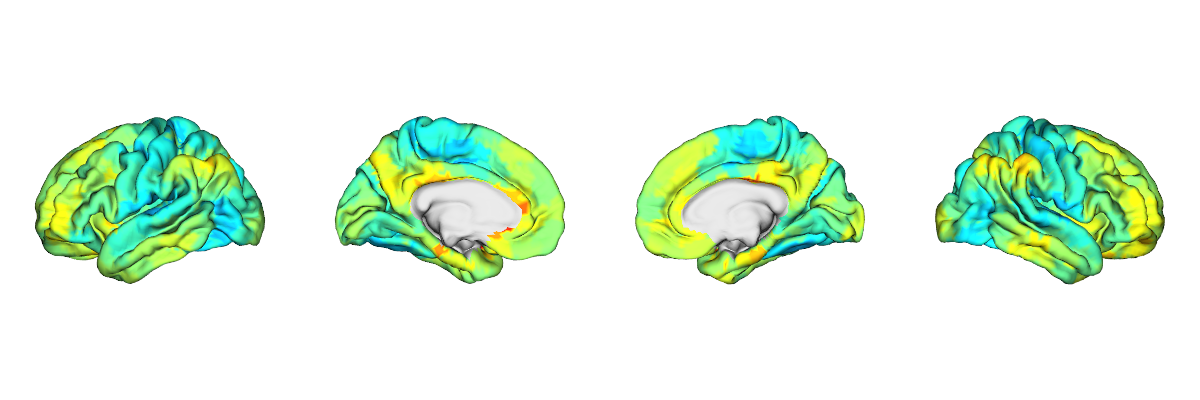

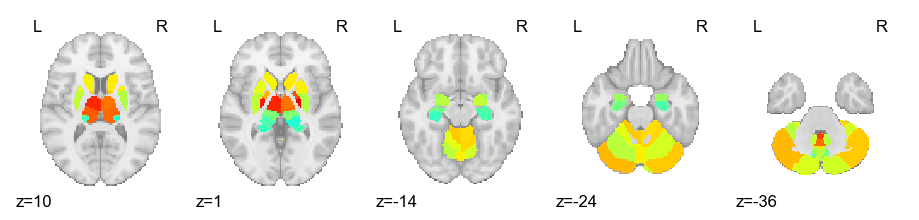

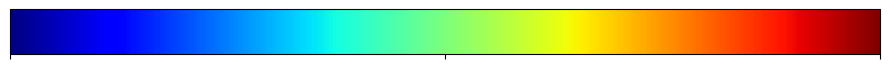

CAP 7 color range:
['-4.5', '0.0', '4.5']




In [10]:
plt.rcParams['font.family'] = 'Arial'
from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
import numpy as np

n_clusters = [7]
colormap = "jet"
cap_disc=["DMN+/VAN,SMN-", "SMN,VAN+/DMN-", "DMN+/VAN-", "FPN+/VN-", "VAN,VN+/CER,FPN,DMN-", "SMN+/THA-", "THA+/SMN-"]

for k in n_clusters:
    caps_file = os.path.join(base_dir, f'coactivation_patterns_{runs_str}',
                        f'caps_nclust-{k}', f'CAPcenter_paired_nclust-{k}_zscored.nii.gz')
    
    plots_dir = results_fig_dir
    os.makedirs(plots_dir, exist_ok=True)

    for cap_idx, cap in enumerate(range(1, k+1)):

        surf_plot_path = os.path.join(plots_dir, f"CAP{cap}_surf.png")
        subcortical_plot_path = os.path.join(plots_dir, f'CAP{cap}_subcortical.png')
        colorbar_path = os.path.join(plots_dir, f'CAP{cap}_colorbar.png')

        cap_img = nib.load(caps_file).slicer[:,:,:,cap_idx]

        # Transform data using subcortical masker
        cap_subcortical_masked = sub_cortical_atlas.fit_transform(cap_img)
        caps_subcortical_nii = sub_cortical_atlas.inverse_transform(cap_subcortical_masked)
        max_val_sub = np.max(cap_subcortical_masked)
        min_val_sub = np.min(cap_subcortical_masked)

        # Project onto surface
        l_surf_cap = surface.vol_to_surf(cap_img, surf_mesh=fsaverage["pial_left"], inner_mesh=fsaverage["white_left"], interpolation='nearest_most_frequent')
        r_surf_cap = surface.vol_to_surf(cap_img, surf_mesh=fsaverage["pial_right"], inner_mesh=fsaverage["white_right"], interpolation='nearest_most_frequent')
        cap_surf = np.concatenate((l_surf_cap, r_surf_cap))
        max_val_surf = np.nanmax(cap_surf)
        min_val_surf = np.nanmin(cap_surf)

        max_val = np.max([max_val_sub, max_val_surf])
        min_val = np.min([min_val_sub, min_val_surf])

        # Create symmetric range for this CAP
        abs_max = max(abs(min_val), abs(max_val))

        # Plot surface (without colorbar)
        cap_surf_masked = np.where(mask, cap_surf, np.nan)
        cap_plt = cap_surf_masked
        surf_plt = plot_hemispheres(surf_lh, surf_rh,
                         array_name=cap_plt,
                         size=(1200, 400),
                         color_bar=False,  # No colorbar for surface plot
                         cmap=colormap,
                         interactive=True,
                         embed_nb=True,
                         screenshot=True,
                         filename=surf_plot_path,
                         background=(1, 1, 1),
                         nan_color=(0.8, 0.8, 0.8, 1),
                         transparent_bg=True,
                         color_range=(-abs_max, abs_max))

        display(Image(filename=surf_plot_path))
        #plt.close()

        # Plot subcortical (without colorbar)
        subcortical_disp = plotting.plot_anat(
            draw_cross=False,
            black_bg=False,
            colorbar=False,
            display_mode="z",
            cut_coords=[10,1,-14,-24,-36],
            annotate=True
        )
        # Add overlay with z-scored data and CAP-specific scaling
        subcortical_disp.add_overlay(
            img=caps_subcortical_nii,
            colorbar=False,  # No colorbar for subcortical plot
            cmap=colormap,
            vmin=-abs_max,
            vmax=abs_max
        )

        # Adjust figure size and save subcortical plot
        fig = plt.gcf()
        fig.set_size_inches((9, 2))
        fig.patch.set_facecolor('none')  # Make figure background transparent
        fig.patch.set_alpha(0.0)         # Set alpha to 0 for full transparency
        plt.tight_layout()
        fig.savefig(subcortical_plot_path, dpi=500, bbox_inches='tight')
        plt.show()
        plt.close()

        # Create separate colorbar figure
        fig_cbar = plt.figure(figsize=(9,0.75))  # Tall and narrow figure for colorbar
        ax_cbar = fig_cbar.add_subplot(111)

        # Remove the axes
        #ax_cbar.set_position([0.3, 0.1, 0.4, 0.8])  # [left, bottom, width, height]

        # Create colorbar
        cmap = plt.cm.jet
        norm = Normalize(vmin=-abs_max, vmax=abs_max)
        cb = ColorbarBase(ax_cbar, cmap=cmap, norm=norm, orientation='horizontal')

        # Set ticks and labels (0 and the two extremes)
        ticks = [-abs_max, 0, abs_max]
        cb.set_ticks(ticks)
        cb.set_ticklabels([f"{tick:.1f}" for tick in ticks])
        # Remove for now and add in photoshop
        cb.set_ticklabels([f"" for tick in ticks])
        cb.ax.tick_params(labelsize=42)
        cb.set_label('', fontsize=20)

        # Save colorbar
        fig_cbar.patch.set_facecolor('none')  # Transparent background
        fig_cbar.patch.set_alpha(0.0)
        plt.tight_layout()
        fig_cbar.savefig(colorbar_path, dpi=500, bbox_inches='tight',
                         facecolor='none', edgecolor='none')
        plt.show()
        plt.close(fig_cbar)

        print(f"CAP {cap} color range:")
        print([f"{tick:.1f}" for tick in ticks])
        print("\n")